In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

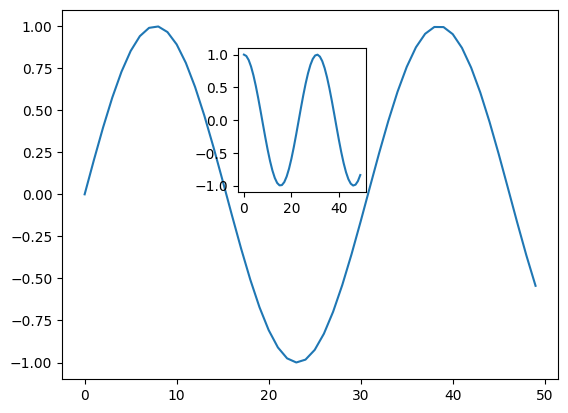

In [3]:
x = np.linspace(0, 10, 50)
ax1 = plt.axes()
ax1.plot(np.sin(x))
# нижний, левый, ширина, высота - все величины нормализованы
ax2 = plt.axes([0.4, 0.5, 0.2, 0.3])
ax2.plot(np.cos(x))
plt.show()

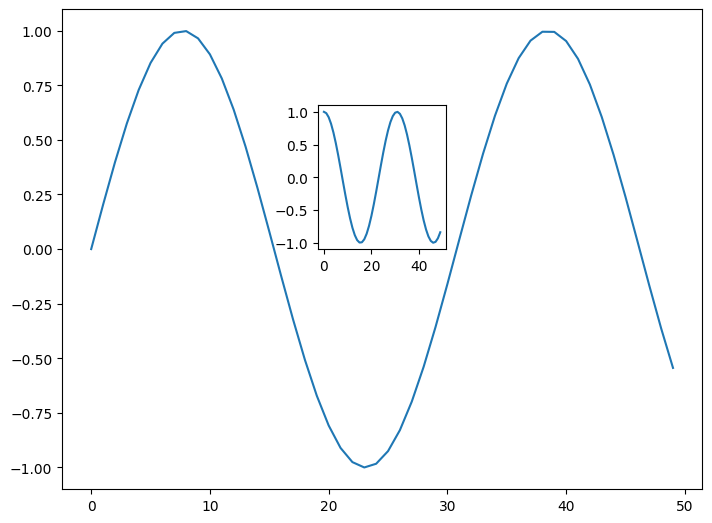

In [4]:
fig = plt.figure()
ax1 = fig.add_axes([0, 0, 1, 1])
ax2 = fig.add_axes([0.4, 0.5, 0.2, 0.3])
ax1.plot(np.sin(x))
ax2.plot(np.cos(x))

plt.show()

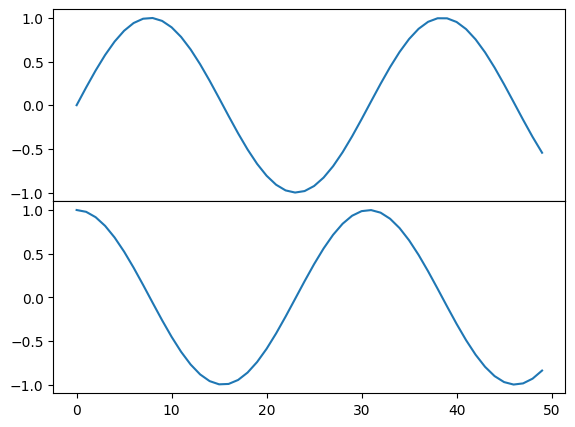

In [5]:
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4])
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4])
ax1.plot(np.sin(x))
ax2.plot(np.cos(x))


plt.show()

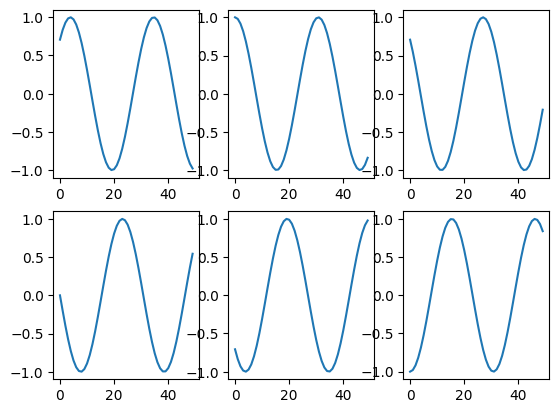

In [6]:
fig = plt.figure()
for i in range(1, 7):

    ax1 = fig.add_subplot(2, 3, i)
    ax1.plot(np.sin(x + np.pi/4 * i))


plt.show()

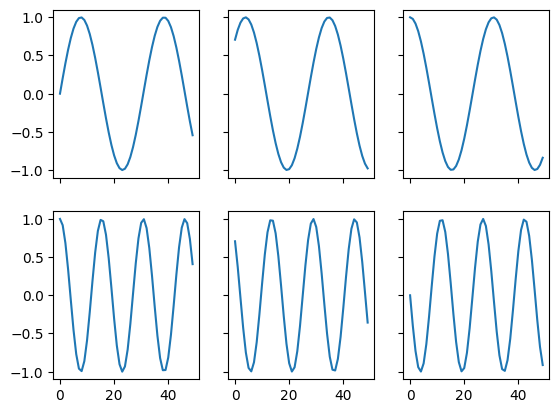

In [7]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')
x1 = np.linspace(0, 10, 50)
x2 = np.linspace(0, 20, 50)
for i in range(2):
    for j in range(3):
        if i % 2 == 0:
            ax[i, j].plot(np.sin(x1 + np.pi/4 * (2*i + j)))
        else:
            ax[i, j].plot(np.sin(x2 + np.pi/4 * (2*i + j)))


plt.show()

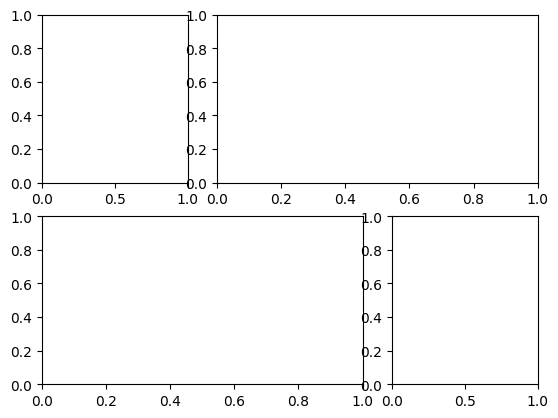

In [8]:
grid = plt.GridSpec(2, 3)

plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1:])

plt.subplot(grid[1, :2])
plt.subplot(grid[1, 2])

plt.show()

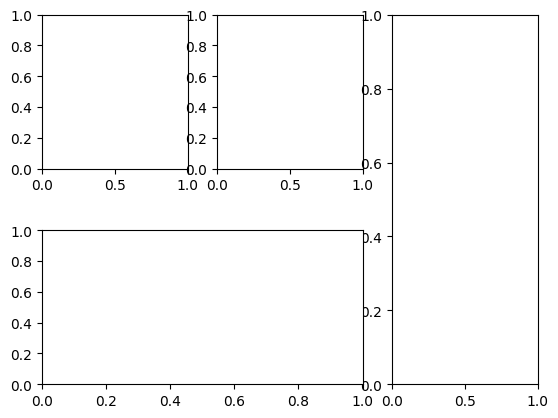

In [9]:
grid = plt.GridSpec(2, 3, wspace=0.2, hspace=0.4)

plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1])

plt.subplot(grid[:, 2])
plt.subplot(grid[1, :2])


plt.show()

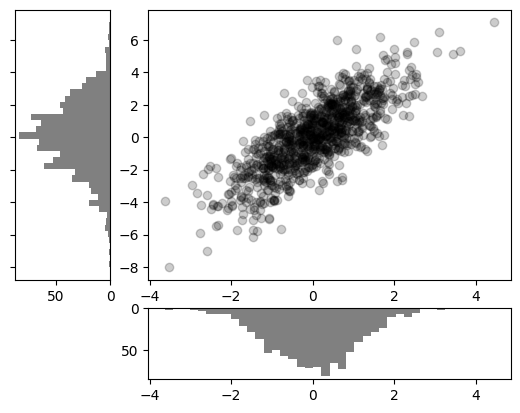

In [10]:
import warnings
warnings.filterwarnings('ignore')

grid = plt.GridSpec(4, 4, wspace=0.4, hspace=0.4)

rng = np.random.default_rng(1)
x, y = rng.multivariate_normal([0, 0], [[1, 2], [3, 4]], 1000).T

y_axes = plt.subplot(grid[:-1, 0], yticklabels=[])
main_axes = plt.subplot(grid[:-1, 1:])
x_axes = plt.subplot(grid[-1, 1:])

main_axes.plot(x, y, 'ok', alpha = 0.2)

y_axes.hist(y, 40, orientation='horizontal', color='grey')
y_axes.invert_xaxis()

x_axes.hist(x, 40, color='grey')
x_axes.invert_yaxis()


plt.show()

In [11]:
births = pd.read_csv("D:/Obsidian/base/-Python/Python libraries/assets/br.csv", sep=';')


for col in ['year', 'month', 'day']:
    births[col] = births[col].astype(int)


births.index = pd.to_datetime(
    births['year'] * 10000 + births['month'] * 100 + births['day'],
    format='%Y%m%d',
    errors='coerce'
)

print(births)

            year  month  day gender  births
1969-01-01  1969      1    1      F    4046
1969-01-01  1969      1    1      M    4440
1969-01-02  1969      1    2      F    4454
1969-01-02  1969      1    2      M    4548
1969-01-03  1969      1    3      F    4548
...          ...    ...  ...    ...     ...
1969-04-02  1969      4    2      F    4766
1969-04-02  1969      4    2      M    5212
1969-04-03  1969      4    3      F    4682
1969-04-03  1969      4    3      M    4848
1969-04-04  1969      4    4      F    4718

[199 rows x 5 columns]


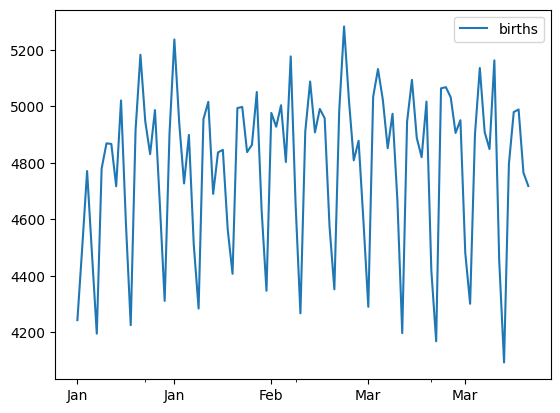

In [12]:
births_dom = births.pivot_table("births",
    index=[births.index.month, births.index.day])

from datetime import datetime 

#births_dom.index = [datetime(1969, mount, day) for (mount, day) in births_dom.index]

fig, ax = plt.subplots()

births_dom.plot(ax=ax)
ax.xaxis.set_minor_locator(mpl.dates.MonthLocator(bymonthday=15))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%h'))

ax.annotate('Тексты аннотации', xy=(1969-1-1, 5500), xytext=('1969-4-1', 4500),
            arrowprops=dict(facecolor='black'))


plt.show()

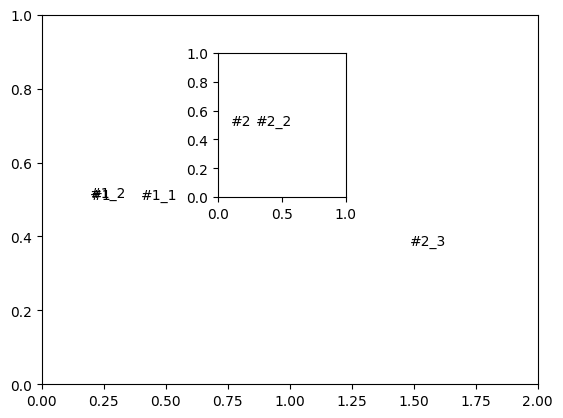

In [13]:
x = np.linspace(0, 10, 50)
fig = plt.figure()
ax1 = plt.axes()

ax1.set_xlim(0, 2)
# нижний, левый, ширина, высота - все величины нормализованы
ax2 = plt.axes([0.4, 0.5, 0.2, 0.3])

ax1.text(0.2, 0.5, '#1', transform=ax1.transData)
ax2.text(0.1, 0.5, '#2', transform=ax2.transData)

ax1.text(0.2, 0.5, '#1_1', transform=ax1.transAxes)
ax2.text(0.3, 0.5, '#2_2', transform=ax2.transAxes)

ax1.text(0.2, 0.5, '#1_2', transform=fig.transFigure)
ax2.text(0.7, 0.4, '#2_3', transform=fig.transFigure)

plt.show()